In [1]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Annotated

load_dotenv()

True

In [2]:
class ChatbotState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
def chat_node(state: ChatbotState) -> dict:

    llm = ChatGroq(
        model="openai/gpt-oss-20b",
        max_tokens=1024
    )

    response = llm.invoke(state["messages"])

    return {"messages": [response]}

In [4]:
graph = StateGraph(ChatbotState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

In [6]:
checkpointer = InMemorySaver()

config = {
    "configurable" : {
        "thread_id": "thread_1"
    }
}

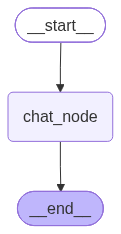

In [7]:
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [12]:
input_state = {
    "messages": [
        SystemMessage("You are a helpful chatbot. Answer in short if needed.")
    ]
}

while True:
    input_query = input("Enter Query: ")

    if input_query.strip().lower() in ["exit", "bye", "goodbye", "quit"]:
        break

    input_state = {
        "messages": [HumanMessage(input_query)]
    }

    output_state = chatbot.invoke(input_state, config=config)

    print("AI: ", output_state["messages"][-1].content)

AI:  Hello, Aryan! What can I do for you today?
AI:  Narendra Modi.
AI:  You’re Aryan.
AI:  22
AI:  264


In [13]:
from pprint import pprint

In [14]:
pprint(output_state["messages"])

[SystemMessage(content='You are a helpful chatbot. Answer in short if needed.', additional_kwargs={}, response_metadata={}, id='b65eb456-79a9-4307-b4db-6fd94637e468'),
 HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='80e43c97-f79d-4069-b0f2-d38185c16749'),
 AIMessage(content='Hi! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". The instructions: "You are a helpful chatbot. Answer in short if needed." So we respond politely: "Hello! How can I help you today?" That\'s short.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 87, 'total_tokens': 146, 'completion_time': 0.062417199, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.00476519, 'prompt_tokens_details': None, 'queue_time': 0.280584437, 'total_time': 0.067182389}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c9afb2bdb4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'mo